# Land Use README Graphic

This notebook generates a before/after image from the Land Use sample B raster using `multiclean.clean_array`. The PNG is saved to `assets/land_use_b_before_after.png` for use in the README.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio as rio
from multiclean import clean_array

Using: /home/nick/Documents/MultiClean/notebooks/data/land use b.tif
Saved figure to /home/nick/Documents/MultiClean/assets/land_use_before_after.png


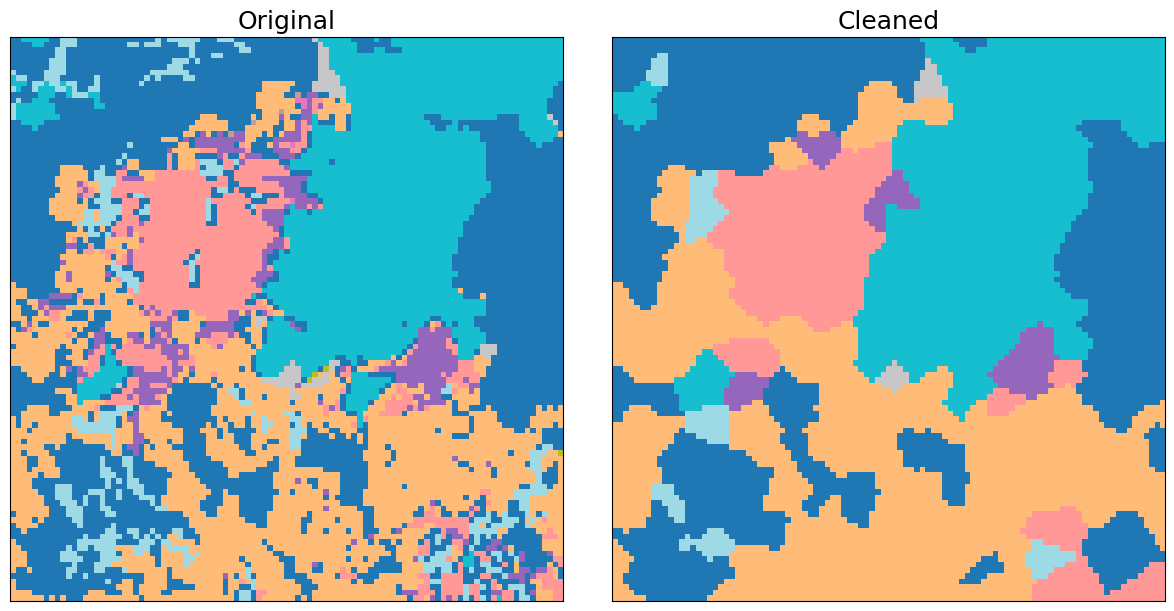

In [2]:
# Resolve data directory whether running from repo root or notebooks/
cwd = Path.cwd()
data_dir = cwd.parent / "notebooks/data"

b_path = data_dir / "land use b.tif"
print("Using:", b_path)

# Load B raster (single-band integer classes)
array_b = rio.open(b_path).read(1)

# Clean with parameters tuned for B
array_b_cleaned = clean_array(
    array=array_b, smooth_edge_size=3, min_island_size=10, connectivity=8
)

# Plot: side-by-side before/after with crisp rendering
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
cmap = plt.get_cmap("tab20")
axes[0].imshow(array_b, cmap=cmap, interpolation="nearest")
axes[0].set_title("Original", fontsize=18)

axes[1].imshow(array_b_cleaned, cmap=cmap, interpolation="nearest")
axes[1].set_title("Cleaned", fontsize=18)
# Remove ticks
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

# Save high-DPI image into repo assets for README
repo_root = cwd if (cwd / "assets").exists() else cwd.parent
assets_dir = repo_root / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
out_path = assets_dir / "land_use_before_after.png"
fig.savefig(out_path, dpi=220, bbox_inches="tight")
print("Saved figure to", out_path)
plt.show()